In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


### Distribution de l'âge au diagnostic (Avant nettoyage)

Histogramme de l'âge des patientes au moment du diagnostic.

In [ ]:
metabric_age_data = metabric_df['age_at_diagnosis'].dropna()
plt.figure(figsize=(8, 5))
plt.hist(metabric_age_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(metabric_age_data.mean(), color='red', linestyle='--', label=f"Moyenne: {metabric_age_data.mean():.1f}")
plt.xlabel('Age au diagnostic')
plt.ylabel('Fréquence')
plt.title(f"Distribution de l'âge (Manquants: {metabric_df['age_at_diagnosis'].isnull().sum()})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Distribution de la taille de la tumeur (Avant nettoyage)

Histogramme de la taille tumorale en millimètres.

In [ ]:
metabric_size_data = pd.to_numeric(metabric_df['tumor_size'], errors='coerce').dropna()
plt.figure(figsize=(8, 5))
plt.hist(metabric_size_data, bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(metabric_size_data.median(), color='blue', linestyle='--', label=f"Médiane: {metabric_size_data.median():.1f} mm")
plt.xlabel('Taille de la tumeur (mm)')
plt.ylabel('Fréquence')
plt.title(f"Distribution de la taille (Manquants: {metabric_df['tumor_size'].isnull().sum()})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Distribution des ganglions positifs (Avant nettoyage)

Histogramme du nombre de ganglions positifs.

In [ ]:
metabric_ln_data = pd.to_numeric(metabric_df['lymph_nodes_examined_positive'], errors='coerce').dropna()
plt.figure(figsize=(8, 5))
plt.hist(metabric_ln_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(metabric_ln_data.median(), color='red', linestyle='--', label=f"Médiane: {metabric_ln_data.median():.1f}")
plt.xlabel('Ganglions positifs')
plt.ylabel('Fréquence')
plt.title(f"Distribution des ganglions (Manquants: {metabric_df['lymph_nodes_examined_positive'].isnull().sum()})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Distribution du grade histologique (Avant nettoyage)

Barres du grade histologique.

In [ ]:
metabric_grade_data = metabric_df['neoplasm_histologic_grade'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(metabric_grade_data.index.astype(str), metabric_grade_data.values, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.xlabel('Grade histologique')
plt.ylabel('Effectif')
plt.title(f"Distribution du grade (Manquants: {metabric_df['neoplasm_histologic_grade'].isnull().sum()})")
plt.grid(alpha=0.3, axis='y')
plt.show()


### Distribution de la cellularité (Avant nettoyage)

Barres des catégories de cellularité.

In [ ]:
metabric_cell_data = metabric_df['cellularity'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(range(len(metabric_cell_data)), metabric_cell_data.values, color='salmon', edgecolor='black', alpha=0.7)
plt.xticks(range(len(metabric_cell_data)), metabric_cell_data.index, rotation=45)
plt.ylabel('Effectif')
plt.title(f"Distribution de la cellularité (Manquants: {metabric_df['cellularity'].isnull().sum()})")
plt.grid(alpha=0.3, axis='y')
plt.show()


### Distribution du stade tumoral (Avant nettoyage)

Barres du stade tumoral.

In [ ]:
metabric_stage_data = metabric_df['tumor_stage'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(metabric_stage_data.index.astype(str), metabric_stage_data.values, color='gold', edgecolor='black', alpha=0.7)
plt.xlabel('Stade tumoral')
plt.ylabel('Effectif')
plt.title(f"Distribution du stade (Manquants: {metabric_df['tumor_stage'].isnull().sum()})")
plt.grid(alpha=0.3, axis='y')
plt.show()


In [25]:
metabric_df = pd.read_csv("C:\\Users\\maram\\Desktop\\Breast_Cancer_Detection_ML_Project\\data\\row\\METABRIC_RNA_Mutation.csv", low_memory=False)

print(f"Dataset loaded: {metabric_df.shape}")
metabric_backup = metabric_df.copy()

Dataset loaded: (1904, 693)



=== DATA EXPLORATION ===

Patients:  1,904
Columns: 693

Top 15 columns with missing values:
 1. tumor_stage                             :    501 ( 26.3%)
 2. 3-gene_classifier_subtype               :    204 ( 10.7%)
 3. primary_tumor_laterality                :    106 (  5.6%)
 4. neoplasm_histologic_grade               :     72 (  3.8%)
 5. cellularity                             :     54 (  2.8%)
 6. mutation_count                          :     45 (  2.4%)
 7. er_status_measured_by_ihc               :     30 (  1.6%)
 8. type_of_breast_surgery                  :     22 (  1.2%)
 9. tumor_size                              :     20 (  1.1%)
 10. cancer_type_detailed                    :     15 (  0.8%)
 11. tumor_other_histologic_subtype          :     15 (  0.8%)
 12. oncotree_code                           :     15 (  0.8%)
 13. death_from_cancer                       :      1 (  0.1%)


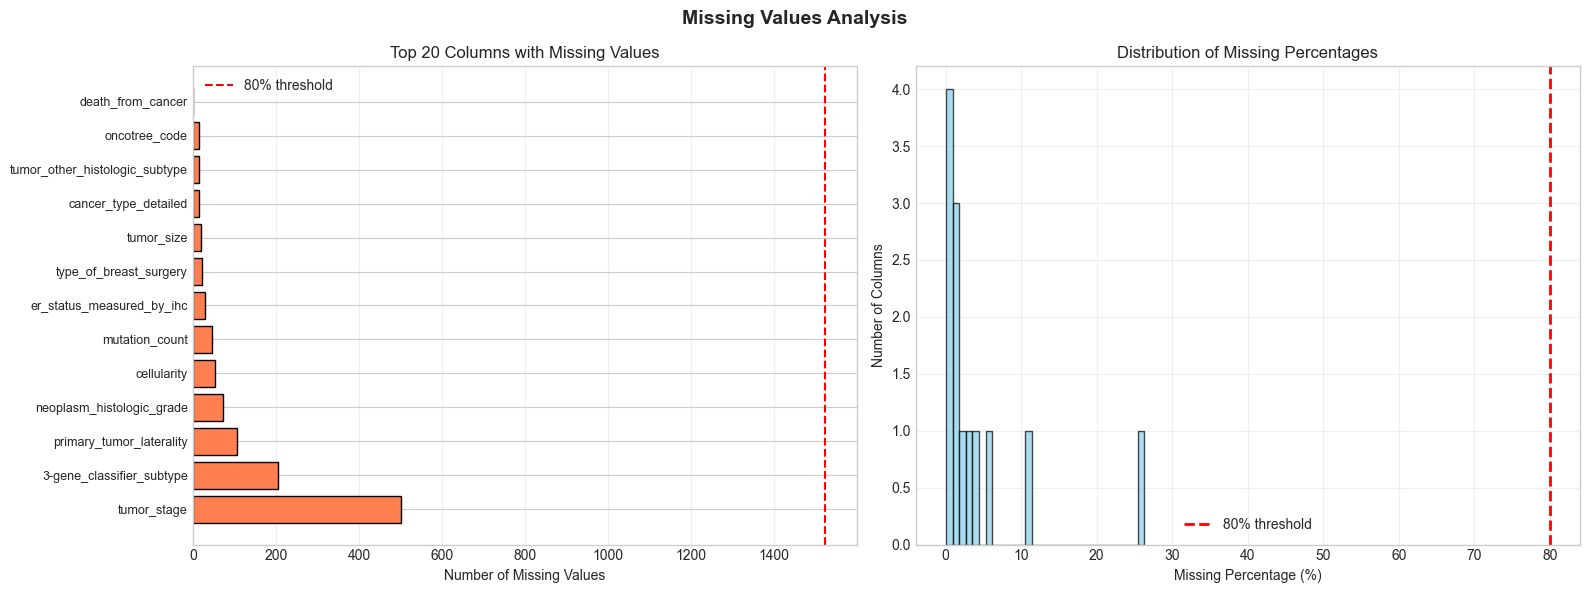


Clinical variables statistics:


,age_at_diagnosis,tumor_size,tumor_stage,neoplasm_histologic_grade,lymph_nodes_examined_positive,overall_survival_months,nottingham_prognostic_index
count,1904.000000,1884.000000,1403.000000,1832.000000,1904.000000,1904.000000,1904.000000
mean,61.087054,26.238726,1.750535,2.415939,2.002101,125.121324,4.033019
std,12.978711,15.160976,0.628999,0.650612,4.079993,76.334148,1.144492
min,21.930000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,51.375000,17.000000,1.000000,2.000000,0.000000,60.825000,3.046000
50%,61.770000,23.000000,2.000000,3.000000,0.000000,115.616667,4.042000
75%,70.592500,30.000000,2.000000,3.000000,2.000000,184.716667,5.040250
max,96.290000,182.000000,4.000000,3.000000,45.000000,355.200000,6.360000



Key distributions (before cleaning):


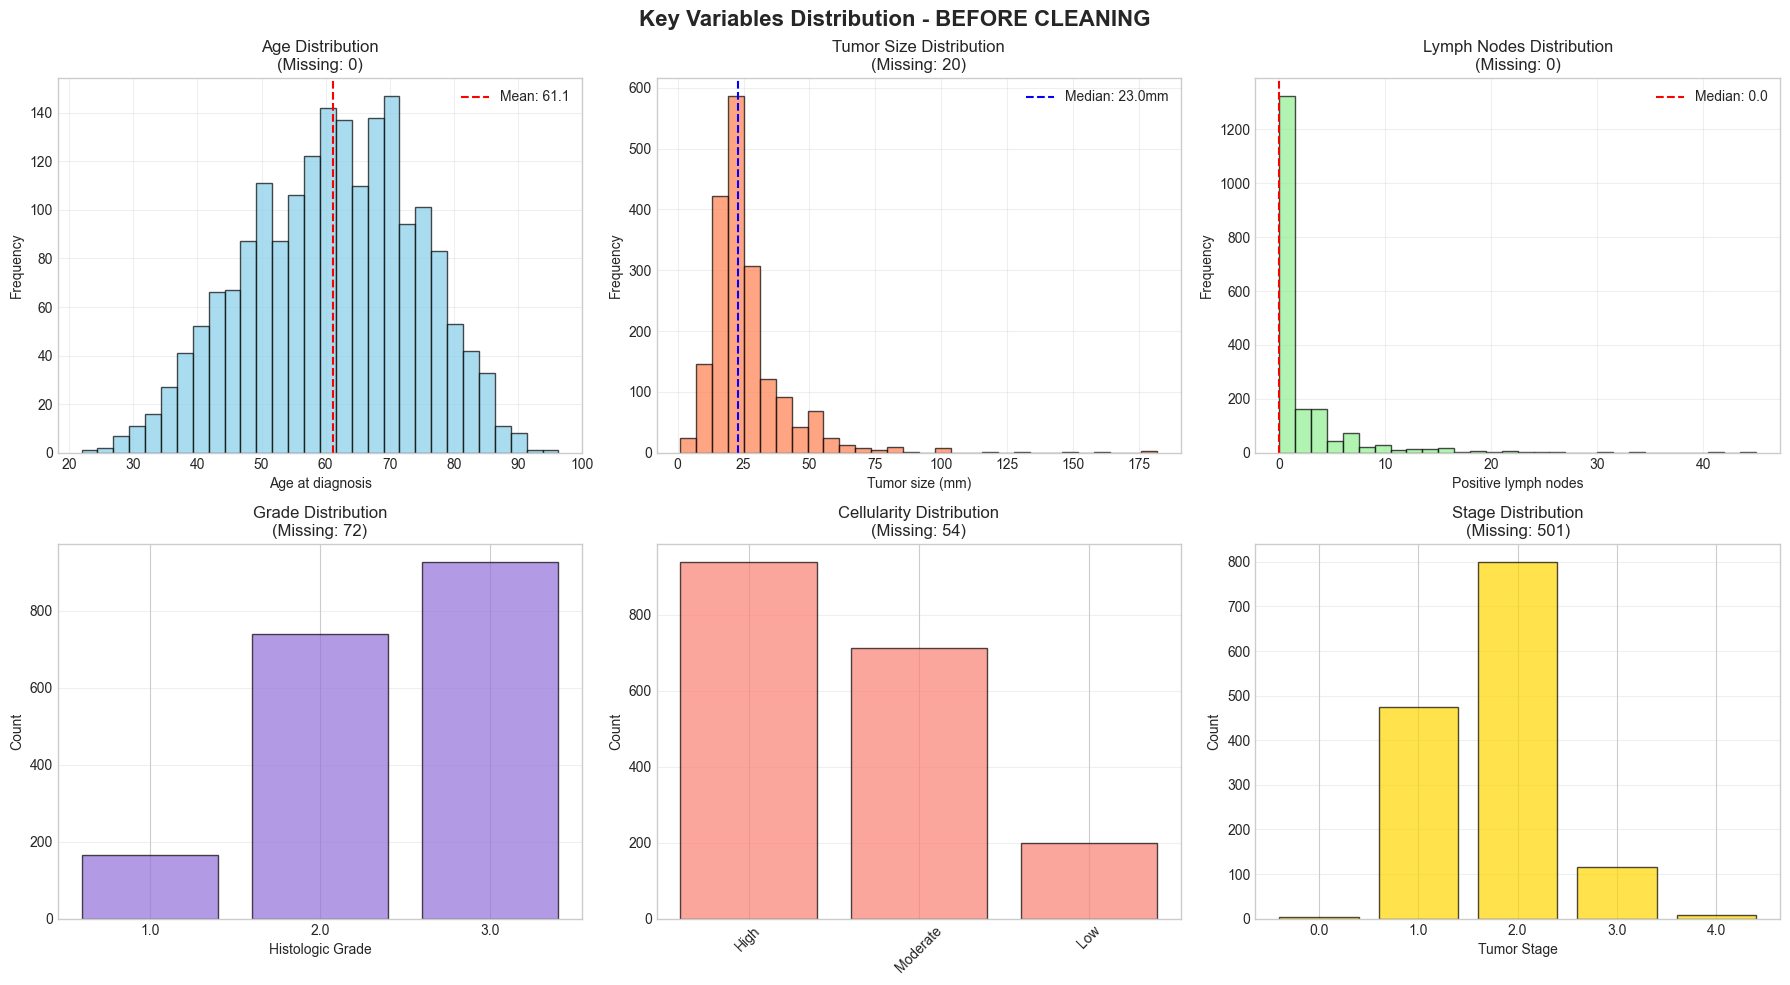

In [26]:
print("\n=== DATA EXPLORATION ===\n")
print(f"Patients:  {len(metabric_df):,}")
print(f"Columns: {len(metabric_df.columns)}")

# Missing values
metabric_missing_cols = metabric_df.isnull().sum()
metabric_missing_cols = metabric_missing_cols[metabric_missing_cols > 0]. sort_values(ascending=False)

print(f"\nTop 15 columns with missing values:")
for i, (col, count) in enumerate(metabric_missing_cols.head(15).items(), 1):
    metabric_pct = (count / len(metabric_df)) * 100
    print(f"{i: 2d}. {col:40s}:  {count:5d} ({metabric_pct: 5.1f}%)")

# Visualize missing
metabric_fig, metabric_axes = plt.subplots(1, 2, figsize=(16, 6))
metabric_fig.suptitle('Missing Values Analysis', fontsize=14, fontweight='bold')

metabric_top_missing = metabric_missing_cols.head(20)
metabric_axes[0].barh(range(len(metabric_top_missing)), metabric_top_missing.values, color='coral', edgecolor='black')
metabric_axes[0].set_yticks(range(len(metabric_top_missing)))
metabric_axes[0]. set_yticklabels(metabric_top_missing. index, fontsize=9)
metabric_axes[0].set_xlabel('Number of Missing Values')
metabric_axes[0].set_title('Top 20 Columns with Missing Values')
metabric_axes[0]. axvline(x=len(metabric_df)*0.8, color='red', linestyle='--', label='80% threshold')
metabric_axes[0].legend()
metabric_axes[0]. grid(alpha=0.3, axis='x')

metabric_missing_pct = (metabric_df.isnull().sum() / len(metabric_df) * 100).sort_values(ascending=False)
metabric_missing_pct = metabric_missing_pct[metabric_missing_pct > 0]
metabric_axes[1].hist(metabric_missing_pct, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
metabric_axes[1].axvline(x=80, color='red', linestyle='--', linewidth=2, label='80% threshold')
metabric_axes[1].set_xlabel('Missing Percentage (%)')
metabric_axes[1].set_ylabel('Number of Columns')
metabric_axes[1].set_title('Distribution of Missing Percentages')
metabric_axes[1].legend()
metabric_axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Clinical stats
metabric_clinical_cols = ['age_at_diagnosis', 'tumor_size', 'tumor_stage', 
                          'neoplasm_histologic_grade', 'lymph_nodes_examined_positive',
                          'overall_survival_months', 'nottingham_prognostic_index']
metabric_available_clinical = [col for col in metabric_clinical_cols if col in metabric_df.columns]

if metabric_available_clinical: 
    print("\nClinical variables statistics:")
    display(metabric_df[metabric_available_clinical].describe())

# Distributions
print("\nKey distributions (before cleaning):")
metabric_fig2, metabric_axes2 = plt.subplots(2, 3, figsize=(18, 10))
metabric_fig2.suptitle('Key Variables Distribution - BEFORE CLEANING', fontsize=16, fontweight='bold')

if 'age_at_diagnosis' in metabric_df.columns:
    metabric_age_data = metabric_df['age_at_diagnosis'].dropna()
    metabric_axes2[0, 0].hist(metabric_age_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    metabric_axes2[0, 0].axvline(metabric_age_data.mean(), color='red', linestyle='--', 
                                  label=f'Mean: {metabric_age_data.mean():.1f}')
    metabric_axes2[0, 0].set_xlabel('Age at diagnosis')
    metabric_axes2[0, 0].set_ylabel('Frequency')
    metabric_axes2[0, 0].set_title(f'Age Distribution\n(Missing: {metabric_df["age_at_diagnosis"].isnull().sum()})')
    metabric_axes2[0, 0].legend()
    metabric_axes2[0, 0].grid(alpha=0.3)

if 'tumor_size' in metabric_df.columns:
    metabric_size_data = pd.to_numeric(metabric_df['tumor_size'], errors='coerce').dropna()
    metabric_axes2[0, 1].hist(metabric_size_data, bins=30, color='coral', edgecolor='black', alpha=0.7)
    metabric_axes2[0, 1].axvline(metabric_size_data.median(), color='blue', linestyle='--', 
                                  label=f'Median: {metabric_size_data.median():.1f}mm')
    metabric_axes2[0, 1].set_xlabel('Tumor size (mm)')
    metabric_axes2[0, 1]. set_ylabel('Frequency')
    metabric_axes2[0, 1].set_title(f'Tumor Size Distribution\n(Missing: {metabric_df["tumor_size"].isnull().sum()})')
    metabric_axes2[0, 1].legend()
    metabric_axes2[0, 1].grid(alpha=0.3)

if 'lymph_nodes_examined_positive' in metabric_df.columns:
    metabric_ln_data = pd.to_numeric(metabric_df['lymph_nodes_examined_positive'], errors='coerce').dropna()
    metabric_axes2[0, 2].hist(metabric_ln_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    metabric_axes2[0, 2].axvline(metabric_ln_data.median(), color='red', linestyle='--', 
                                  label=f'Median: {metabric_ln_data.median():.1f}')
    metabric_axes2[0, 2]. set_xlabel('Positive lymph nodes')
    metabric_axes2[0, 2].set_ylabel('Frequency')
    metabric_axes2[0, 2].set_title(f'Lymph Nodes Distribution\n(Missing: {metabric_df["lymph_nodes_examined_positive"].isnull().sum()})')
    metabric_axes2[0, 2].legend()
    metabric_axes2[0, 2].grid(alpha=0.3)

if 'neoplasm_histologic_grade' in metabric_df.columns:
    metabric_grade_data = metabric_df['neoplasm_histologic_grade'].value_counts().sort_index()
    metabric_axes2[1, 0].bar(metabric_grade_data.index. astype(str), metabric_grade_data.values, 
                              color='mediumpurple', edgecolor='black', alpha=0.7)
    metabric_axes2[1, 0].set_xlabel('Histologic Grade')
    metabric_axes2[1, 0].set_ylabel('Count')
    metabric_axes2[1, 0].set_title(f'Grade Distribution\n(Missing: {metabric_df["neoplasm_histologic_grade"].isnull().sum()})')
    metabric_axes2[1, 0].grid(alpha=0.3, axis='y')

if 'cellularity' in metabric_df.columns:
    metabric_cell_data = metabric_df['cellularity'].value_counts()
    metabric_axes2[1, 1].bar(range(len(metabric_cell_data)), metabric_cell_data.values, 
                              color='salmon', edgecolor='black', alpha=0.7)
    metabric_axes2[1, 1].set_xticks(range(len(metabric_cell_data)))
    metabric_axes2[1, 1].set_xticklabels(metabric_cell_data.index, rotation=45)
    metabric_axes2[1, 1].set_ylabel('Count')
    metabric_axes2[1, 1].set_title(f'Cellularity Distribution\n(Missing: {metabric_df["cellularity"].isnull().sum()})')
    metabric_axes2[1, 1].grid(alpha=0.3, axis='y')

if 'tumor_stage' in metabric_df.columns:
    metabric_stage_data = metabric_df['tumor_stage']. value_counts().sort_index()
    metabric_axes2[1, 2].bar(metabric_stage_data.index.astype(str), metabric_stage_data.values, 
                              color='gold', edgecolor='black', alpha=0.7)
    metabric_axes2[1, 2].set_xlabel('Tumor Stage')
    metabric_axes2[1, 2].set_ylabel('Count')
    metabric_axes2[1, 2].set_title(f'Stage Distribution\n(Missing: {metabric_df["tumor_stage"].isnull().sum()})')
    metabric_axes2[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [27]:
print("\n=== COLUMN SELECTION ===\n")

metabric_columns_to_keep = [
    'patient_id', 'age_at_diagnosis', 'tumor_size', 'tumor_stage',
    'neoplasm_histologic_grade', 'cellularity', 'nottingham_prognostic_index',
    'er_status', 'her2_status', 'pr_status', 'lymph_nodes_examined_positive',
    'pam50_+_claudin-low_subtype', 'integrative_cluster', '3-gene_classifier_subtype',
    'mutation_count', 'pik3ca_mut', 'tp53_mut', 'gata3_mut', 'map3k1_mut', 'cdh1_mut',
    'overall_survival_months', 'overall_survival', 'death_from_cancer'
]

metabric_available_keep = [col for col in metabric_columns_to_keep if col in metabric_df. columns]
metabric_selected = metabric_df[metabric_available_keep]. copy()

print(f"Dataset reduction: {metabric_df.shape[1]} -> {metabric_selected.shape[1]} columns")

# Remove >80% missing
metabric_high_nan_threshold = 0.8
metabric_high_nan_cols = []

for col in metabric_selected.columns:
    metabric_nan_pct = metabric_selected[col].isnull().sum() / len(metabric_selected)
    if metabric_nan_pct > metabric_high_nan_threshold:
        metabric_high_nan_cols.append((col, metabric_nan_pct))

if metabric_high_nan_cols:
    print(f"\nColumns with >{metabric_high_nan_threshold*100}% missing (removed):")
    for col, pct in metabric_high_nan_cols:
        print(f"  {col}: {pct*100:.1f}%")
    
    metabric_cols_drop_high_nan = [col for col, _ in metabric_high_nan_cols]
    metabric_selected = metabric_selected.drop(columns=metabric_cols_drop_high_nan)
    print(f"\nFinal shape: {metabric_selected. shape}")


=== COLUMN SELECTION ===

Dataset reduction: 693 -> 23 columns


In [29]:
print("\n=== DATA CLEANING ===\n")

metabric_clean = metabric_selected.copy()
print(f"Missing values before:  {metabric_clean.isnull().sum().sum()}")

# Numeric imputation
metabric_numeric_cols = ['age_at_diagnosis', 'tumor_size', 'lymph_nodes_examined_positive',
                         'nottingham_prognostic_index', 'overall_survival_months', 'mutation_count']
metabric_available_numeric = [col for col in metabric_numeric_cols if col in metabric_clean.columns]

print("\nImputing numeric variables (median):")
for col in metabric_available_numeric: 
    metabric_nan_before = metabric_clean[col].isnull().sum()
    if metabric_nan_before > 0:
        metabric_clean[col] = pd.to_numeric(metabric_clean[col], errors='coerce')
        metabric_median_val = metabric_clean[col].median()
        metabric_clean[col]. fillna(metabric_median_val, inplace=True)
        print(f"  {col}: {metabric_nan_before} NaN -> median={metabric_median_val:.2f}")

# Categorical imputation
metabric_categorical_cols = ['tumor_stage', 'neoplasm_histologic_grade', 'cellularity',
                              'er_status', 'her2_status', 'pr_status',
                              'pam50_+_claudin-low_subtype', 'integrative_cluster',
                              '3-gene_classifier_subtype']
metabric_available_categorical = [col for col in metabric_categorical_cols if col in metabric_clean.columns]

print("\nImputing categorical variables (mode):")
for col in metabric_available_categorical: 
    metabric_nan_before = metabric_clean[col].isnull().sum()
    if metabric_nan_before > 0:
        metabric_mode_val = metabric_clean[col].mode()[0] if len(metabric_clean[col].mode()) > 0 else 'Unknown'
        metabric_clean[col].fillna(metabric_mode_val, inplace=True)
        print(f"  {col}: {metabric_nan_before} NaN -> mode='{metabric_mode_val}'")

# Mutation imputation
metabric_mutation_cols_impute = [col for col in metabric_clean.columns if col.endswith('_mut')]
if metabric_mutation_cols_impute:
    print("\nImputing mutation variables (0):")
    for col in metabric_mutation_cols_impute:
        metabric_nan_before = metabric_clean[col].isnull().sum()
        if metabric_nan_before > 0:
            metabric_clean[col]. fillna(0, inplace=True)
            print(f"  {col}: {metabric_nan_before} NaN -> 0")

print(f"\nMissing values after:  {metabric_clean.isnull().sum().sum()}")


=== DATA CLEANING ===

Missing values before:  897

Imputing numeric variables (median):
  tumor_size: 20 NaN -> median=23.00
  mutation_count: 45 NaN -> median=5.00

Imputing categorical variables (mode):
  tumor_stage: 501 NaN -> mode='2.0'
  neoplasm_histologic_grade: 72 NaN -> mode='3.0'
  cellularity: 54 NaN -> mode='High'
  3-gene_classifier_subtype: 204 NaN -> mode='ER+/HER2- Low Prolif'

Imputing mutation variables (0):

Missing values after:  1



=== OUTLIER DETECTION ===



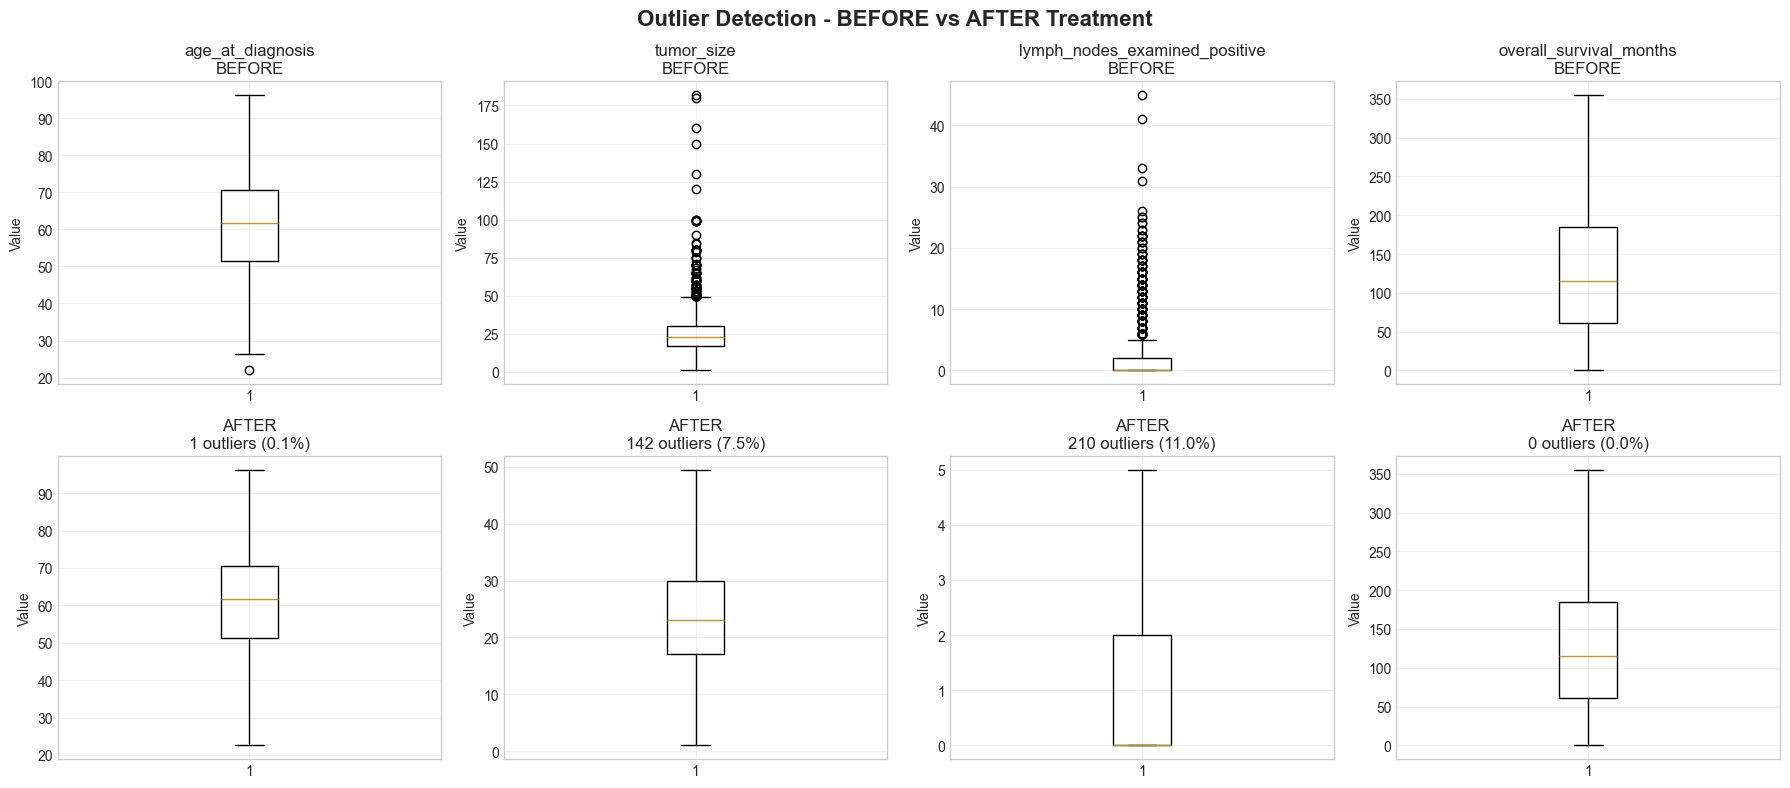


Outlier treatment:
  OK       age_at_diagnosis                        :    1 outliers (  0.1%)
  TREATED  tumor_size                              :  142 outliers (  7.5%)
  TREATED  lymph_nodes_examined_positive           :  210 outliers ( 11.0%)
  OK       overall_survival_months                 :    0 outliers (  0.0%)

Final shape: (1904, 23)
Cleaning completed!


In [ ]:
print("\n=== OUTLIER DETECTION ===\n")

def metabric_detect_and_cap_outliers(df, column):
    metabric_data = df[column].copy()
    metabric_Q1 = metabric_data.quantile(0.25)
    metabric_Q3 = metabric_data. quantile(0.75)
    metabric_IQR = metabric_Q3 - metabric_Q1
    metabric_lower_bound = metabric_Q1 - 1.5 * metabric_IQR
    metabric_upper_bound = metabric_Q3 + 1.5 * metabric_IQR
    
    metabric_outliers_low = (metabric_data < metabric_lower_bound).sum()
    metabric_outliers_high = (metabric_data > metabric_upper_bound).sum()
    metabric_total_outliers = metabric_outliers_low + metabric_outliers_high
    metabric_pct_outliers = (metabric_total_outliers / len(metabric_data)) * 100
    
    metabric_data_capped = metabric_data. clip(lower=metabric_lower_bound, upper=metabric_upper_bound)
    
    return metabric_data_capped, {
        'n_outliers':  metabric_total_outliers,
        'pct':  metabric_pct_outliers,
        'lower_bound': metabric_lower_bound,
        'upper_bound': metabric_upper_bound
    }

metabric_outlier_check_cols = ['age_at_diagnosis', 'tumor_size', 
                                'lymph_nodes_examined_positive', 'overall_survival_months']
metabric_available_outlier = [col for col in metabric_outlier_check_cols if col in metabric_clean.columns]

metabric_outlier_results = {}

for col in metabric_available_outlier:
    metabric_data_capped, metabric_stats = metabric_detect_and_cap_outliers(metabric_clean, col)
    metabric_outlier_results[col] = {'data': metabric_data_capped, 'stats': metabric_stats}

print("Outlier treatment:")
for col in metabric_available_outlier:
    metabric_stats = metabric_outlier_results[col]['stats']
    
    if metabric_stats['pct'] > 5:
        metabric_clean[col] = metabric_outlier_results[col]['data']
        metabric_status = "TREATED"
    else:
        metabric_status = "OK"
    
    print(f"  {metabric_status: 8s} {col:40s}: {metabric_stats['n_outliers']: 4d} outliers ({metabric_stats['pct']: 5.1f}%)")

print(f"\nFinal shape:  {metabric_clean.shape}")

In [30]:
print("\n=== ENCODING CATEGORICAL VARIABLES ===\n")

# Binary encoding
metabric_binary_cols = {
    'er_status': {'Positive': 1, 'Positve': 1, 'Negative': 0},
    'her2_status':  {'Positive': 1, 'Negative': 0},
    'pr_status': {'Positive': 1, 'Negative': 0}
}

for col, mapping in metabric_binary_cols.items():
    if col in metabric_clean. columns:
        metabric_clean[col] = metabric_clean[col].fillna('Unknown')
        metabric_clean[col + '_binary'] = metabric_clean[col].map(mapping)
        
        if metabric_clean[col + '_binary'].isnull().sum() > 0:
            metabric_mode_val = metabric_clean[col + '_binary'].mode()[0] if len(metabric_clean[col + '_binary'].mode()) > 0 else 0
            metabric_clean[col + '_binary']. fillna(metabric_mode_val, inplace=True)

# Ordinal encoding - Tumor stage
if 'tumor_stage' in metabric_clean.columns:
    metabric_stage_map = {'0. 0': 0, '0':  0, '1.0': 1, '1':  1, '2.0':  2, '2': 2, '3.0': 3, '3': 3, '4.0': 4, '4': 4}
    metabric_clean['tumor_stage_encoded'] = metabric_clean['tumor_stage'].astype(str).map(metabric_stage_map)
    
    if metabric_clean['tumor_stage_encoded'].isnull().sum() > 0:
        metabric_median_stage = metabric_clean['tumor_stage_encoded'].median()
        metabric_clean['tumor_stage_encoded']. fillna(metabric_median_stage, inplace=True)

# Grade
if 'neoplasm_histologic_grade' in metabric_clean.columns:
    metabric_grade_map = {'1. 0': 1, '1': 1, '2.0': 2, '2': 2, '3.0': 3, '3': 3}
    metabric_clean['neoplasm_histologic_grade_encoded'] = metabric_clean['neoplasm_histologic_grade'].astype(str).map(metabric_grade_map)
    
    if metabric_clean['neoplasm_histologic_grade_encoded']. isnull().sum() > 0:
        metabric_mode_grade = metabric_clean['neoplasm_histologic_grade_encoded'].mode()[0]
        metabric_clean['neoplasm_histologic_grade_encoded'].fillna(metabric_mode_grade, inplace=True)

# Cellularity
if 'cellularity' in metabric_clean.columns:
    metabric_cell_map = {'Low': 0, 'Moderate': 1, 'High':  2}
    metabric_clean['cellularity_encoded'] = metabric_clean['cellularity'].map(metabric_cell_map)
    
    if metabric_clean['cellularity_encoded'].isnull().sum() > 0:
        metabric_mode_cell = metabric_clean['cellularity_encoded'].mode()[0]
        metabric_clean['cellularity_encoded'].fillna(metabric_mode_cell, inplace=True)

# Label encoding
metabric_nominal_cols = ['pam50_+_claudin-low_subtype', 'integrative_cluster', '3-gene_classifier_subtype']

for col in metabric_nominal_cols:
    if col in metabric_clean.columns:
        metabric_clean[col] = metabric_clean[col].fillna('Unknown')
        metabric_le = LabelEncoder()
        metabric_clean[col + '_encoded'] = metabric_le.fit_transform(metabric_clean[col]. astype(str))

# Overall survival
if 'overall_survival' in metabric_clean. columns:
    metabric_survival_map = {'LIVING': 1, 'Living': 1, 'DECEASED': 0, 'Deceased': 0}
    metabric_clean['overall_survival_binary'] = metabric_clean['overall_survival'].map(metabric_survival_map)
    
    if metabric_clean['overall_survival_binary'].isnull().sum() > 0:
        metabric_clean['overall_survival_binary'].fillna(0, inplace=True)

# Death from cancer
if 'death_from_cancer' in metabric_clean.columns:
    metabric_death_map = {'Living': 0, 'Died of Disease': 1, 'Died of Other Causes': 0}
    metabric_clean['death_from_cancer_binary'] = metabric_clean['death_from_cancer'].map(metabric_death_map)
    
    if metabric_clean['death_from_cancer_binary'].isnull().sum() > 0:
        metabric_clean['death_from_cancer_binary']. fillna(0, inplace=True)

print("Encoding completed!")


=== ENCODING CATEGORICAL VARIABLES ===

Encoding completed!


In [31]:
# Suppression colonnes mutations (non utilisées dans DSO3)
metabric_mutation_cols = ['pik3ca_mut', 'tp53_mut', 'gata3_mut', 'map3k1_mut', 'cdh1_mut']
metabric_cols_to_drop = [col for col in metabric_mutation_cols if col in metabric_clean.columns]

print(f"Suppression {len(metabric_cols_to_drop)} colonnes mutations")
print(f"Shape avant : {metabric_clean. shape}")

metabric_clean = metabric_clean.drop(columns=metabric_cols_to_drop)

print(f"Shape après : {metabric_clean.shape}")

Suppression 5 colonnes mutations
Shape avant : (1904, 34)
Shape après : (1904, 29)



=== FEATURE ENGINEERING ===

Creating combined features:
  ✓ hormone_receptor_score (ER + PR)
  ✓ triple_negative (ER- & HER2- & PR-)
  ✓ size_category (>median)
  ✓ grade_stage_interaction (grade × stage)
  ✓ high_risk (grade + stage)


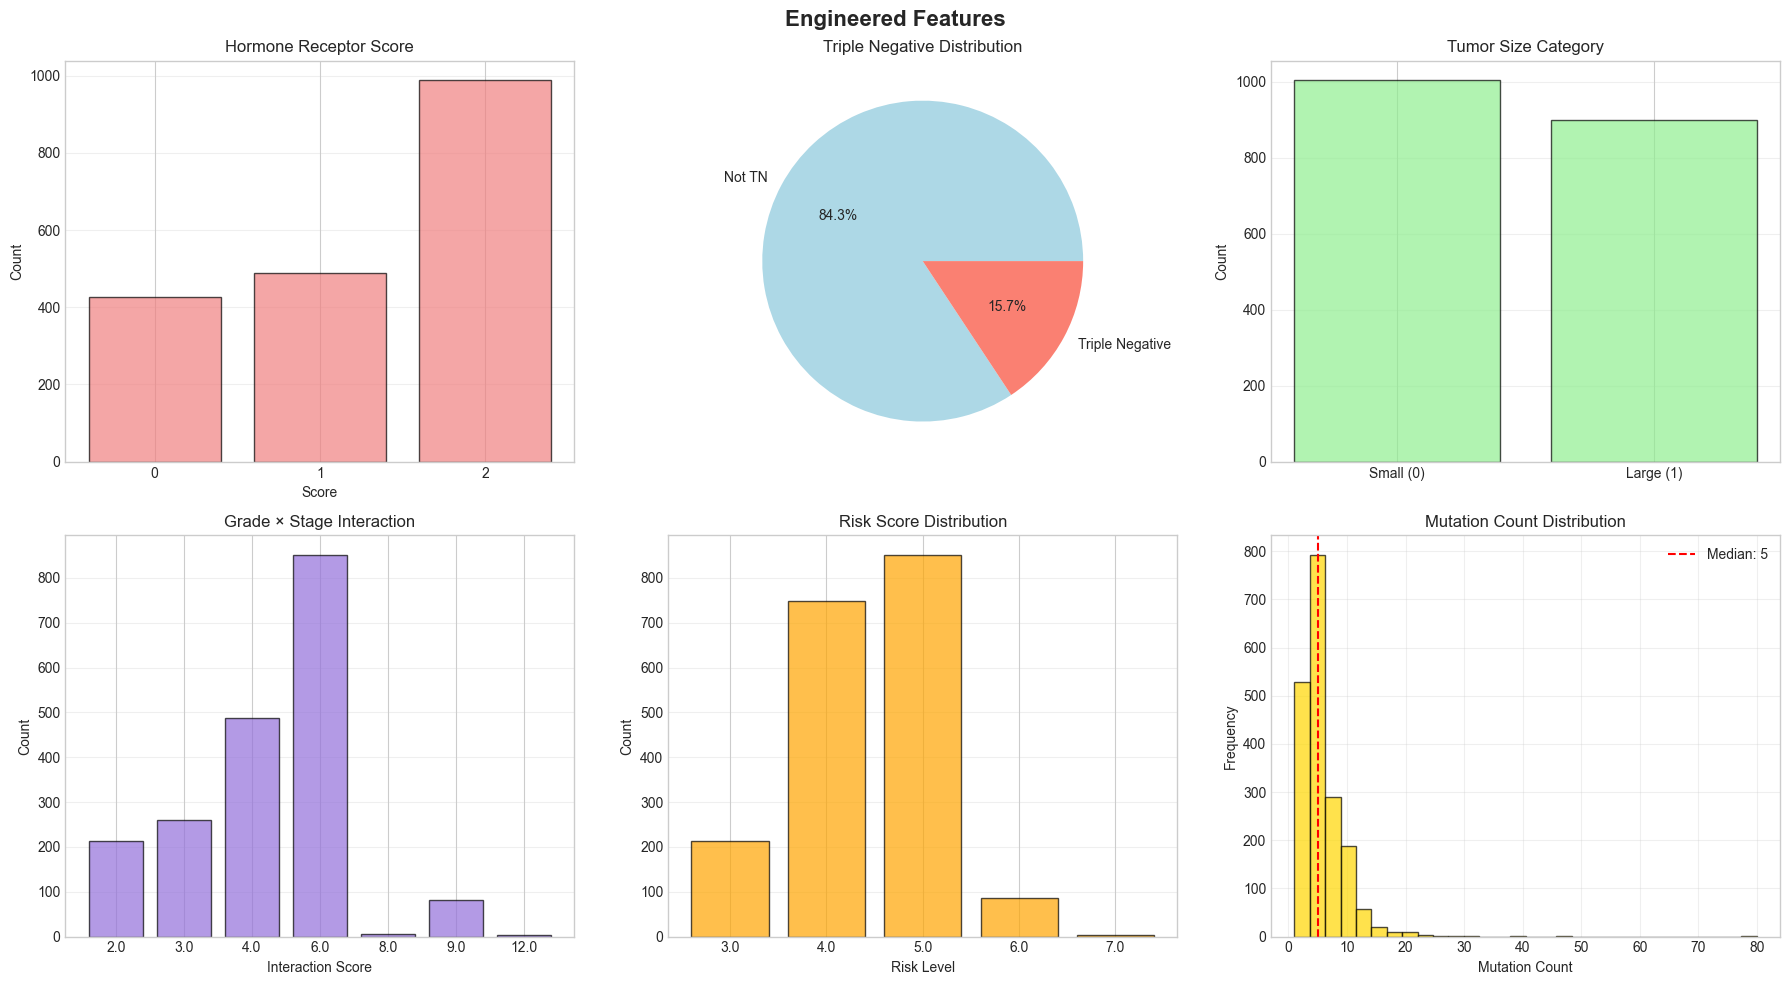


Feature engineering completed!


In [32]:
print("\n=== FEATURE ENGINEERING ===\n")

# Créer des features combinées
print("Creating combined features:")

# 1. Hormone Receptor Score
if all(col in metabric_clean.columns for col in ['er_status_binary', 'pr_status_binary']):
    metabric_clean['hormone_receptor_score'] = metabric_clean['er_status_binary'] + metabric_clean['pr_status_binary']
    print("  ✓ hormone_receptor_score (ER + PR)")

# 2. Triple Negative
if all(col in metabric_clean.columns for col in ['er_status_binary', 'her2_status_binary', 'pr_status_binary']):
    metabric_clean['triple_negative'] = (
        (metabric_clean['er_status_binary'] == 0) & 
        (metabric_clean['her2_status_binary'] == 0) & 
        (metabric_clean['pr_status_binary'] == 0)
    ). astype(int)
    print("  ✓ triple_negative (ER- & HER2- & PR-)")

# 3. Size Category
if 'tumor_size' in metabric_clean.columns:
    metabric_clean['size_category'] = (metabric_clean['tumor_size'] > metabric_clean['tumor_size'].median()).astype(int)
    print("  ✓ size_category (>median)")

# 4. Grade-Stage Interaction
if all(col in metabric_clean.columns for col in ['neoplasm_histologic_grade_encoded', 'tumor_stage_encoded']):
    metabric_clean['grade_stage_interaction'] = (
        metabric_clean['neoplasm_histologic_grade_encoded'] * metabric_clean['tumor_stage_encoded']
    )
    print("  ✓ grade_stage_interaction (grade × stage)")

# 5.  High Risk
if all(col in metabric_clean.columns for col in ['neoplasm_histologic_grade_encoded', 'tumor_stage_encoded']):
    metabric_clean['high_risk'] = (
        (metabric_clean['neoplasm_histologic_grade_encoded'] == 3) & 
        (metabric_clean['tumor_stage_encoded'] >= 2)
    ).astype(int)
    # Catégories: 0=Low, 1=Medium, 2=High, 3=Very High
    metabric_clean['high_risk'] = (
        metabric_clean['neoplasm_histologic_grade_encoded'] + 
        metabric_clean['tumor_stage_encoded']
    )
    print("  ✓ high_risk (grade + stage)")

# Visualiser les nouvelles features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Engineered Features', fontsize=16, fontweight='bold')

# Hormone receptor score
if 'hormone_receptor_score' in metabric_clean.columns:
    hr_counts = metabric_clean['hormone_receptor_score'].value_counts().sort_index()
    axes[0, 0].bar(hr_counts.index.astype(str), hr_counts.values, 
                   color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Hormone Receptor Score')
    axes[0, 0].grid(alpha=0.3, axis='y')

# Triple negative
if 'triple_negative' in metabric_clean.columns:
    tn_counts = metabric_clean['triple_negative'].value_counts()
    axes[0, 1].pie(tn_counts.values, labels=['Not TN', 'Triple Negative'], 
                   autopct='%1.1f%%', colors=['lightblue', 'salmon'])
    axes[0, 1].set_title('Triple Negative Distribution')

# Size category
if 'size_category' in metabric_clean.columns:
    size_cat_counts = metabric_clean['size_category'].value_counts()
    axes[0, 2].bar(['Small (0)', 'Large (1)'], 
                   [size_cat_counts.get(0, 0), size_cat_counts.get(1, 0)],
                   color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 2]. set_ylabel('Count')
    axes[0, 2].set_title('Tumor Size Category')
    axes[0, 2].grid(alpha=0.3, axis='y')

# Grade-stage interaction
if 'grade_stage_interaction' in metabric_clean. columns:
    gs_counts = metabric_clean['grade_stage_interaction'].value_counts(). sort_index()
    axes[1, 0].bar(gs_counts.index.astype(str), gs_counts.values, 
                   color='mediumpurple', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Interaction Score')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Grade × Stage Interaction')
    axes[1, 0].grid(alpha=0.3, axis='y')

# High risk
if 'high_risk' in metabric_clean.columns:
    risk_counts = metabric_clean['high_risk'].value_counts(). sort_index()
    axes[1, 1].bar(risk_counts.index.astype(str), risk_counts.values, 
                   color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Risk Level')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Risk Score Distribution')
    axes[1, 1].grid(alpha=0.3, axis='y')

# Mutation count
if 'mutation_count' in metabric_clean.columns:
    mut_data = metabric_clean['mutation_count']
    axes[1, 2].hist(mut_data, bins=30, color='gold', edgecolor='black', alpha=0.7)
    axes[1, 2].axvline(mut_data.median(), color='red', linestyle='--', 
                      label=f'Median: {mut_data.median():.0f}')
    axes[1, 2].set_xlabel('Mutation Count')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Mutation Count Distribution')
    axes[1, 2].legend()
    axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFeature engineering completed!")

targets


=== TARGET VARIABLES CREATION ===

Creating target variables:
  ✓ aggressiveness_score (0-10)
  ✓ growth_rate (mm/year, capped at 50)
  ✓ evolution_6m (0=Stable, 1=Moderate, 2=Rapid)


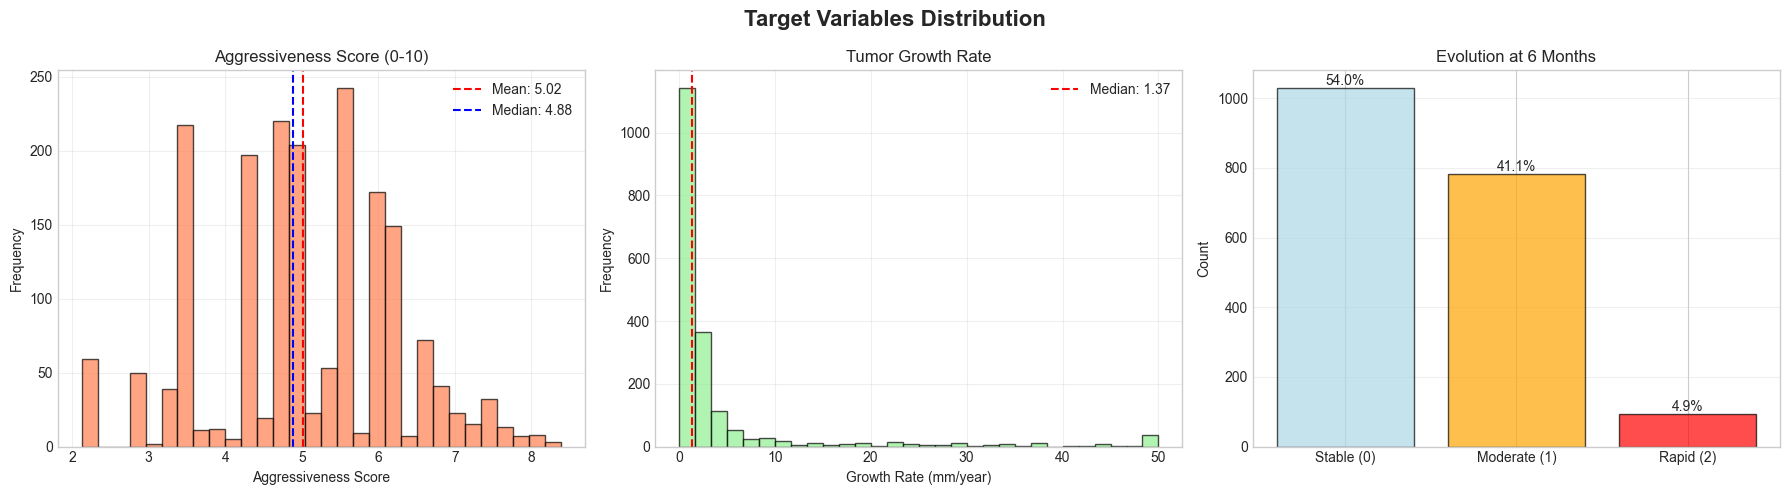


Target variables created!

Target statistics:
  Aggressiveness: mean=5.02, std=1.24
  Growth rate: mean=4.47, std=9.38
  Evolution 6M distribution:
    evolution_6m
0    1028
1     782
2      94
Name: count, dtype: int64


In [34]:
print("\n=== TARGET VARIABLES CREATION ===\n")

# 1. Aggressiveness Score (combinaison de plusieurs facteurs)
print("Creating target variables:")

if all(col in metabric_clean.columns for col in ['neoplasm_histologic_grade', 'tumor_stage', 
                                                   'lymph_nodes_examined_positive', 'nottingham_prognostic_index']):
    
    # Normaliser les composants entre 0 et 1
    grade_norm = metabric_clean['neoplasm_histologic_grade'] / 3
    stage_norm = metabric_clean['tumor_stage'] / 4
    nodes_norm = metabric_clean['lymph_nodes_examined_positive'] / metabric_clean['lymph_nodes_examined_positive'].max()
    npi_norm = (metabric_clean['nottingham_prognostic_index'] - metabric_clean['nottingham_prognostic_index'].min()) / \
               (metabric_clean['nottingham_prognostic_index'].max() - metabric_clean['nottingham_prognostic_index'].min())
    
    # Score d'agressivité (0-10)
    metabric_clean['aggressiveness_score'] = (
        grade_norm * 3 +      # Grade: poids 30%
        stage_norm * 3 +      # Stage: poids 30%
        nodes_norm * 2 +      # Nodes: poids 20%
        npi_norm * 2          # NPI: poids 20%
    )
    
    print("  ✓ aggressiveness_score (0-10)")

# 2. Growth Rate (vitesse de progression estimée)
if all(col in metabric_clean.columns for col in ['tumor_size', 'age_at_diagnosis', 'neoplasm_histologic_grade']):
    
    # Estimer la vitesse de croissance (mm/an)
    # Hypothèse: âge moyen de début = 40 ans
    years_since_onset = np.maximum(metabric_clean['age_at_diagnosis'] - 40, 1)
    metabric_clean['growth_rate'] = (metabric_clean['tumor_size'] / years_since_onset) * \
                                     (metabric_clean['neoplasm_histologic_grade'] / 2)
    
    # Cap à 50 mm/an
    metabric_clean['growth_rate'] = metabric_clean['growth_rate'].clip(upper=50)
    
    print("  ✓ growth_rate (mm/year, capped at 50)")

# 3. Evolution 6M (progression à 6 mois) - Classification
if 'aggressiveness_score' in metabric_clean.columns:
    
    # 0: Stable (score < 5)
    # 1: Progression modérée (5 <= score < 7)
    # 2: Progression rapide (score >= 7)
    
    metabric_clean['evolution_6m'] = pd.cut(
        metabric_clean['aggressiveness_score'],
        bins=[-np.inf, 5, 7, np.inf],
        labels=[0, 1, 2]
    ).astype(int)
    
    print("  ✓ evolution_6m (0=Stable, 1=Moderate, 2=Rapid)")

# Visualiser les cibles
fig, axes = plt. subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variables Distribution', fontsize=16, fontweight='bold')

# Aggressiveness Score
if 'aggressiveness_score' in metabric_clean.columns:
    agg_data = metabric_clean['aggressiveness_score']
    axes[0].hist(agg_data, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[0].axvline(agg_data. mean(), color='red', linestyle='--', 
                   label=f'Mean: {agg_data.mean():.2f}')
    axes[0].axvline(agg_data. median(), color='blue', linestyle='--', 
                   label=f'Median: {agg_data.median():.2f}')
    axes[0].set_xlabel('Aggressiveness Score')
    axes[0].set_ylabel('Frequency')
    axes[0]. set_title('Aggressiveness Score (0-10)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# Growth Rate
if 'growth_rate' in metabric_clean.columns:
    growth_data = metabric_clean['growth_rate']
    axes[1].hist(growth_data, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(growth_data.median(), color='red', linestyle='--', 
                   label=f'Median: {growth_data.median():.2f}')
    axes[1].set_xlabel('Growth Rate (mm/year)')
    axes[1]. set_ylabel('Frequency')
    axes[1].set_title('Tumor Growth Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

# Evolution 6M
if 'evolution_6m' in metabric_clean. columns:
    evol_counts = metabric_clean['evolution_6m'].value_counts(). sort_index()
    colors_evol = ['lightblue', 'orange', 'red']
    axes[2].bar(['Stable (0)', 'Moderate (1)', 'Rapid (2)'], 
                [evol_counts.get(0, 0), evol_counts.get(1, 0), evol_counts.get(2, 0)],
                color=colors_evol, edgecolor='black', alpha=0.7)
    axes[2].set_ylabel('Count')
    axes[2].set_title('Evolution at 6 Months')
    axes[2]. grid(alpha=0.3, axis='y')
    
    # Ajouter les pourcentages
    total = len(metabric_clean)
    for i, count in enumerate([evol_counts.get(0, 0), evol_counts.get(1, 0), evol_counts.get(2, 0)]):
        axes[2].text(i, count, f'{count/total*100:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nTarget variables created!")
print(f"\nTarget statistics:")
if 'aggressiveness_score' in metabric_clean.columns:
    print(f"  Aggressiveness: mean={metabric_clean['aggressiveness_score'].mean():.2f}, "
          f"std={metabric_clean['aggressiveness_score'].std():.2f}")
if 'growth_rate' in metabric_clean.columns:
    print(f"  Growth rate: mean={metabric_clean['growth_rate'].mean():.2f}, "
          f"std={metabric_clean['growth_rate'].std():.2f}")
if 'evolution_6m' in metabric_clean.columns:
    print(f"  Evolution 6M distribution:")
    print(f"    {metabric_clean['evolution_6m'].value_counts().sort_index()}")

In [35]:
print("\n=== FINAL CLEANUP & EXPORT ===\n")

# Supprimer les colonnes originales encodées (garder seulement les versions encodées)
cols_to_drop = [
    'patient_id',
    'er_status', 'her2_status', 'pr_status',
    'tumor_stage', 'neoplasm_histologic_grade', 'cellularity',
    'pam50_+_claudin-low_subtype', 'integrative_cluster', '3-gene_classifier_subtype',
    'overall_survival', 'death_from_cancer'
]

existing_to_drop = [col for col in cols_to_drop if col in metabric_clean.columns]

print(f"Dropping {len(existing_to_drop)} original columns:")
for col in existing_to_drop:
    print(f"  - {col}")

metabric_final = metabric_clean.drop(columns=existing_to_drop)

# Vérifications finales
print(f"\n=== FINAL DATASET SUMMARY ===")
print(f"Shape: {metabric_final. shape}")
print(f"Missing values: {metabric_final.isnull().sum(). sum()}")
print(f"Duplicates: {metabric_final.duplicated().sum()}")

print(f"\nColumns ({len(metabric_final.columns)}):")
for col in metabric_final.columns:
    print(f"  - {col}")

# Statistiques descriptives
print(f"\nDescriptive statistics:")
display(metabric_final.describe())

# Export
output_path = 'data/row/clean_metabric_final1.csv'
metabric_final.to_csv(output_path)
print(f"\n✓ Dataset exported to: {output_path}")




=== FINAL CLEANUP & EXPORT ===

Dropping 12 original columns:
  - patient_id
  - er_status
  - her2_status
  - pr_status
  - tumor_stage
  - neoplasm_histologic_grade
  - cellularity
  - pam50_+_claudin-low_subtype
  - integrative_cluster
  - 3-gene_classifier_subtype
  - overall_survival
  - death_from_cancer

=== FINAL DATASET SUMMARY ===
Shape: (1904, 25)
Missing values: 0
Duplicates: 0

Columns (25):
  - age_at_diagnosis
  - tumor_size
  - nottingham_prognostic_index
  - lymph_nodes_examined_positive
  - mutation_count
  - overall_survival_months
  - er_status_binary
  - her2_status_binary
  - pr_status_binary
  - tumor_stage_encoded
  - neoplasm_histologic_grade_encoded
  - cellularity_encoded
  - pam50_+_claudin-low_subtype_encoded
  - integrative_cluster_encoded
  - 3-gene_classifier_subtype_encoded
  - overall_survival_binary
  - death_from_cancer_binary
  - hormone_receptor_score
  - triple_negative
  - size_category
  - grade_stage_interaction
  - high_risk
  - aggressivenes

,age_at_diagnosis,tumor_size,nottingham_prognostic_index,lymph_nodes_examined_positive,mutation_count,overall_survival_months,er_status_binary,her2_status_binary,pr_status_binary,tumor_stage_encoded,...,overall_survival_binary,death_from_cancer_binary,hormone_receptor_score,triple_negative,size_category,grade_stage_interaction,high_risk,aggressiveness_score,growth_rate,evolution_6m
count,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,...,1904.0,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000,1904.000000
mean,61.087054,26.204706,4.033019,2.002101,5.681197,125.121324,0.766282,0.123950,0.529937,1.820378,...,0.0,0.326681,1.296218,0.157038,0.472164,4.773109,4.431723,5.020863,4.465982,0.509454
std,12.978711,15.084713,1.144492,4.079993,4.011903,76.334148,0.423306,0.329611,0.499234,0.544677,...,0.0,0.469123,0.810121,0.363932,0.499356,1.737954,0.757212,1.238915,9.382485,0.590621
min,21.930000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,2.123881,0.034141,0.000000
25%,51.375000,17.000000,3.046000,0.000000,3.000000,60.825000,1.000000,0.000000,0.000000,2.000000,...,0.0,0.000000,1.000000,0.000000,0.000000,4.000000,4.000000,4.263433,0.815550,0.000000
50%,61.770000,23.000000,4.042000,0.000000,5.000000,115.616667,1.000000,0.000000,1.000000,2.000000,...,0.0,0.000000,2.000000,0.000000,0.000000,4.000000,4.000000,4.884328,1.373776,0.000000
75%,70.592500,30.000000,5.040250,2.000000,7.000000,184.716667,1.000000,0.000000,1.000000,2.000000,...,0.0,1.000000,2.000000,0.000000,1.000000,6.000000,5.000000,6.051907,2.735588,1.000000
max,96.290000,182.000000,6.360000,45.000000,80.000000,355.200000,1.000000,1.000000,1.000000,4.000000,...,0.0,1.000000,2.000000,1.000000,1.000000,12.000000,7.000000,8.384328,50.000000,2.000000



✓ Dataset exported to: data/row/clean_metabric_final1.csv
